In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2
from qiskit_algorithms import VQD
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info.analysis import Z2Symmetries

from scatterer import scatterer
from struc_const import G_AB
from functions import secular_matrix, interpolation, potential

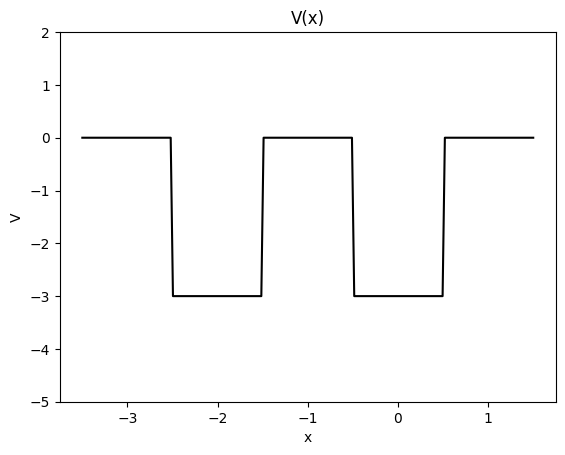

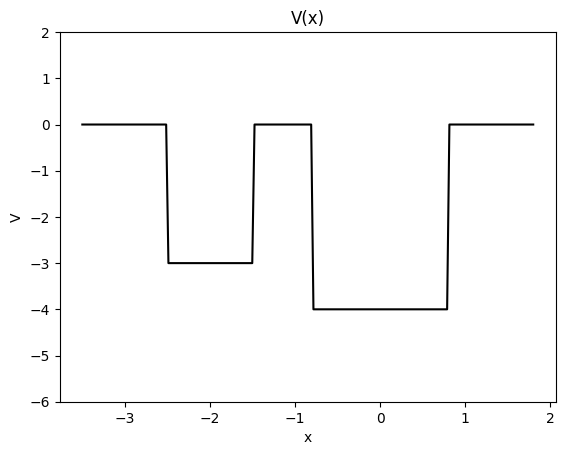

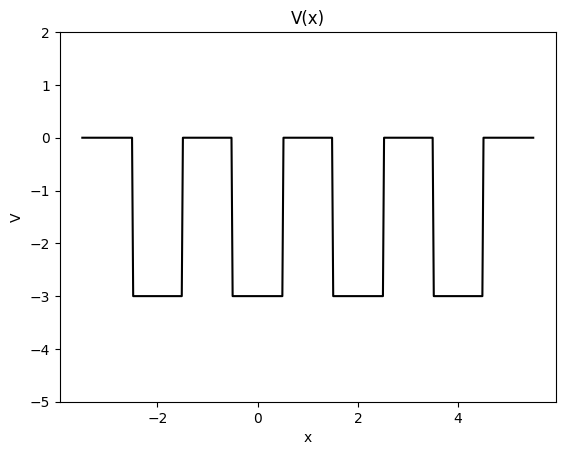

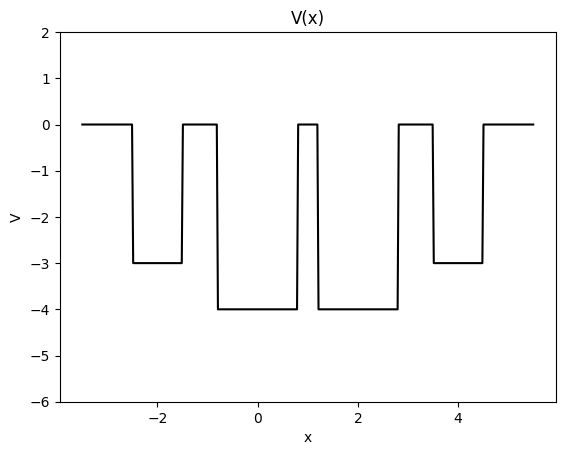

In [ ]:
#Example matrices
energy = -3

s1 = scatterer(0.5, -3)
s2 = scatterer(0.8, -4)

s = [s1, s1]
tab_x = [-2, 0]
matrix1 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s1, s2]
tab_x = [-2, 0]
matrix2 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s1, s1, s1, s1]
tab_x = [-2, 0, 2, 4]
matrix3 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s1, s2, s2, s1]
tab_x = [-2, 0, 2, 4]
matrix4 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

m = [matrix1, matrix2, matrix3, matrix4]

In [3]:
df1 = pd.DataFrame(matrix1)
df2 = pd.DataFrame(matrix2)
df3 = pd.DataFrame(matrix3)
df4 = pd.DataFrame(matrix4)
display(df1, df2, df3, df4)

,0,1,2,3
0,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
1,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,0.429901+0.000000j,0.000000+0.000000j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-3.365939+0.000000j


,0,1,2,3
0,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
1,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,0.032349+0.000000j,0.000000+0.000000j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.363813+0.000000j


,0,1,2,3,4,5,6,7
0,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000980-0.000000j,-0.000000-0.000980j,-0.000031-0.000000j,-0.000000-0.000031j
1,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000980j,-0.000980-0.000000j,-0.000000+0.000031j,-0.000031-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000980-0.000000j,-0.000000-0.000980j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000980j,-0.000980-0.000000j
4,-0.000980-0.000000j,-0.000000+0.000980j,-0.031301-0.000000j,-0.000000+0.031301j,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
5,-0.000000-0.000980j,-0.000980-0.000000j,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
6,-0.000031-0.000000j,-0.000000+0.000031j,-0.000980-0.000000j,-0.000000+0.000980j,-0.031301-0.000000j,-0.000000+0.031301j,0.429901+0.000000j,0.000000+0.000000j
7,-0.000000-0.000031j,-0.000031-0.000000j,-0.000000-0.000980j,-0.000980-0.000000j,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-3.365939+0.000000j


,0,1,2,3,4,5,6,7
0,0.429901+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000980-0.000000j,-0.000000-0.000980j,-0.000031-0.000000j,-0.000000-0.000031j
1,0.000000+0.000000j,-3.365939+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000980j,-0.000980-0.000000j,-0.000000+0.000031j,-0.000031-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,0.032349+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000980-0.000000j,-0.000000-0.000980j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.363813+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000980j,-0.000980-0.000000j
4,-0.000980-0.000000j,-0.000000+0.000980j,-0.031301-0.000000j,-0.000000+0.031301j,0.032349+0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
5,-0.000000-0.000980j,-0.000980-0.000000j,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.363813+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
6,-0.000031-0.000000j,-0.000000+0.000031j,-0.000980-0.000000j,-0.000000+0.000980j,-0.031301-0.000000j,-0.000000+0.031301j,0.429901+0.000000j,0.000000+0.000000j
7,-0.000000-0.000031j,-0.000031-0.000000j,-0.000000-0.000980j,-0.000980-0.000000j,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-3.365939+0.000000j


In [4]:
from qiskit.quantum_info import DensityMatrix
from qiskit import QuantumCircuit

def xor(matrix):
    N = matrix.shape[0]
    num_qubits = int(np.log2(N))
    
    rho = DensityMatrix(matrix)
    qc = QuantumCircuit(num_qubits)
    
    qc.x(0)
    
    return rho.evolve(qc).data


matrix1_xor = xor(matrix1)
matrix2_xor = xor(matrix2)
matrix3_xor = xor(matrix3)
matrix4_xor = xor(matrix4)

df1 = pd.DataFrame(matrix1_xor)
df2 = pd.DataFrame(matrix2_xor)
df3 = pd.DataFrame(matrix3_xor)
df4 = pd.DataFrame(matrix4_xor)

display(df1, df2, df3, df4)

,0,1,2,3
0,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j
1,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j
2,-0.031301+0.000000j,0.000000-0.031301j,-3.365939+0.000000j,0.000000+0.000000j
3,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.429901+0.000000j


,0,1,2,3
0,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j
1,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j
2,-0.031301+0.000000j,0.000000-0.031301j,-0.363813+0.000000j,0.000000+0.000000j
3,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.032349+0.000000j


,0,1,2,3,4,5,6,7
0,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j,-0.000980+0.000000j,0.000000+0.000980j,-0.000031+0.000000j,0.000000+0.000031j
1,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j,0.000000-0.000980j,-0.000980+0.000000j,0.000000-0.000031j,-0.000031+0.000000j
2,-0.031301+0.000000j,0.000000-0.031301j,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j,-0.000980+0.000000j,0.000000+0.000980j
3,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j,0.000000-0.000980j,-0.000980+0.000000j
4,-0.000980+0.000000j,0.000000-0.000980j,-0.031301+0.000000j,0.000000-0.031301j,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j
5,0.000000+0.000980j,-0.000980+0.000000j,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j
6,-0.000031+0.000000j,0.000000-0.000031j,-0.000980+0.000000j,0.000000-0.000980j,-0.031301+0.000000j,0.000000-0.031301j,-3.365939+0.000000j,0.000000+0.000000j
7,0.000000+0.000031j,-0.000031+0.000000j,0.000000+0.000980j,-0.000980+0.000000j,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.429901+0.000000j


,0,1,2,3,4,5,6,7
0,-3.365939+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j,-0.000980+0.000000j,0.000000+0.000980j,-0.000031+0.000000j,0.000000+0.000031j
1,0.000000+0.000000j,0.429901+0.000000j,0.000000-0.031301j,-0.031301+0.000000j,0.000000-0.000980j,-0.000980+0.000000j,0.000000-0.000031j,-0.000031+0.000000j
2,-0.031301+0.000000j,0.000000-0.031301j,-0.363813+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j,-0.000980+0.000000j,0.000000+0.000980j
3,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.032349+0.000000j,0.000000-0.031301j,-0.031301+0.000000j,0.000000-0.000980j,-0.000980+0.000000j
4,-0.000980+0.000000j,0.000000-0.000980j,-0.031301+0.000000j,0.000000-0.031301j,-0.363813+0.000000j,0.000000+0.000000j,-0.031301+0.000000j,0.000000+0.031301j
5,0.000000+0.000980j,-0.000980+0.000000j,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.032349+0.000000j,0.000000-0.031301j,-0.031301+0.000000j
6,-0.000031+0.000000j,0.000000-0.000031j,-0.000980+0.000000j,0.000000-0.000980j,-0.031301+0.000000j,0.000000-0.031301j,-3.365939+0.000000j,0.000000+0.000000j
7,0.000000+0.000031j,-0.000031+0.000000j,0.000000+0.000980j,-0.000980+0.000000j,0.000000+0.031301j,-0.031301+0.000000j,0.000000+0.000000j,0.429901+0.000000j


In [5]:
def fwht(matrix):
    N = matrix.shape[0]
    n = int(np.log2(N))
    
    rho = DensityMatrix(matrix)
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
    
    return rho.evolve(qc).data


matrix1_hadamard = fwht(matrix1_xor)
matrix2_hadamard = fwht(matrix2_xor)
matrix3_hadamard = fwht(matrix3_xor)
matrix4_hadamard = fwht(matrix4_xor)

display(pd.DataFrame(matrix1_hadamard), pd.DataFrame(matrix2_hadamard), pd.DataFrame(matrix3_hadamard), pd.DataFrame(matrix4_hadamard))

,0,1,2,3
0,-1.499320+0.000000j,-1.897920+0.000000j,0.000000+0.000000j,0.000000+0.031301j
1,-1.897920+0.000000j,-1.499320+0.000000j,0.000000-0.031301j,0.000000+0.000000j
2,0.000000+0.000000j,0.000000-0.031301j,-1.436718+0.000000j,-1.897920+0.000000j
3,0.000000+0.031301j,0.000000+0.000000j,-1.897920+0.000000j,-1.436718+0.000000j


,0,1,2,3
0,-0.848177+0.000000j,-1.048000+0.000000j,-0.651143+0.000000j,-0.849919+0.031301j
1,-1.048000+0.000000j,-0.848177+0.000000j,-0.849919-0.031301j,-0.651143+0.000000j
2,-0.651143+0.000000j,-0.849919-0.031301j,-0.785574+0.000000j,-1.048000+0.000000j
3,-0.849919+0.031301j,-0.651143+0.000000j,-1.048000+0.000000j,-0.785574+0.000000j


,0,1,2,3,4,5,6,7
0,-1.515966+0.000000j,-1.897920+0.000000j,0.000000+0.000000j,0.000000+0.015666j,0.000000+0.000000j,0.000000+0.016646j,0.015635+0.000000j,0.000000+0.000000j
1,-1.897920+0.000000j,-1.515966+0.000000j,0.000000-0.015666j,0.000000+0.000000j,0.000000-0.016646j,0.000000+0.000000j,0.000000+0.000000j,0.015635+0.000000j
2,0.000000+0.000000j,0.000000-0.015666j,-1.422032+0.000000j,-1.897920+0.000000j,-0.015635+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.014686j
3,0.000000+0.015666j,0.000000+0.000000j,-1.897920+0.000000j,-1.422032+0.000000j,0.000000+0.000000j,-0.015635+0.000000j,0.000000+0.014686j,0.000000+0.000000j
4,0.000000+0.000000j,0.000000-0.016646j,-0.015635+0.000000j,0.000000+0.000000j,-1.482674+0.000000j,-1.897920+0.000000j,0.000000+0.000000j,0.000000+0.046936j
5,0.000000+0.016646j,0.000000+0.000000j,0.000000+0.000000j,-0.015635+0.000000j,-1.897920+0.000000j,-1.482674+0.000000j,0.000000-0.046936j,0.000000+0.000000j
6,0.015635+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.014686j,0.000000+0.000000j,0.000000-0.046936j,-1.451404+0.000000j,-1.897920+0.000000j
7,0.000000+0.000000j,0.015635+0.000000j,0.000000-0.014686j,0.000000+0.000000j,0.000000+0.046936j,0.000000+0.000000j,-1.897920+0.000000j,-1.451404+0.000000j


,0,1,2,3,4,5,6,7
0,-0.864822+0.000000j,-1.048000+0.000000j,0.000000+0.000000j,0.000000+0.015666j,0.000000+0.000000j,0.000000+0.016646j,-0.635508+0.000000j,-0.849919+0.000000j
1,-1.048000+0.000000j,-0.864822+0.000000j,0.000000-0.015666j,0.000000+0.000000j,0.000000-0.016646j,0.000000+0.000000j,-0.849919+0.000000j,-0.635508+0.000000j
2,0.000000+0.000000j,0.000000-0.015666j,-0.770888+0.000000j,-1.048000+0.000000j,-0.666779+0.000000j,-0.849919+0.000000j,0.000000+0.000000j,0.000000-0.014686j
3,0.000000+0.015666j,0.000000+0.000000j,-1.048000+0.000000j,-0.770888+0.000000j,-0.849919+0.000000j,-0.666779+0.000000j,0.000000+0.014686j,0.000000+0.000000j
4,0.000000+0.000000j,0.000000-0.016646j,-0.666779+0.000000j,-0.849919+0.000000j,-0.831531+0.000000j,-1.048000+0.000000j,0.000000+0.000000j,0.000000+0.046936j
5,0.000000+0.016646j,0.000000+0.000000j,-0.849919+0.000000j,-0.666779+0.000000j,-1.048000+0.000000j,-0.831531+0.000000j,0.000000-0.046936j,0.000000+0.000000j
6,-0.635508+0.000000j,-0.849919+0.000000j,0.000000+0.000000j,0.000000+0.014686j,0.000000+0.000000j,0.000000-0.046936j,-0.800260+0.000000j,-1.048000+0.000000j
7,-0.849919+0.000000j,-0.635508+0.000000j,0.000000-0.014686j,0.000000+0.000000j,0.000000+0.046936j,0.000000+0.000000j,-1.048000+0.000000j,-0.800260+0.000000j


In [6]:

def prefactors(matrix):
    N = matrix.shape[0]
    n = int(np.log2(N))
    A = matrix.copy()
    
    # for r in range(N):
    #     for s in range(N):
    #         k = bin(r & s).count('1')
    #         factor = ((-1j)**k) / (2**n)
    #         A[r, s] *= factor
    
    pauli_sparse = SparsePauliOp.from_operator(A)
    return pauli_sparse.simplify()

pauli1_result = prefactors(matrix1_hadamard)
pauli2_result = prefactors(matrix2_hadamard)
pauli3_result = prefactors(matrix3_hadamard)
pauli4_result = prefactors(matrix4_hadamard)


df1_pauli = pd.DataFrame(pauli1_result.to_list(), columns=['Pauli String', 'Coefficient'])
df2_pauli = pd.DataFrame(pauli2_result.to_list(), columns=['Pauli String', 'Coefficient'])
df3_pauli = pd.DataFrame(pauli3_result.to_list(), columns=['Pauli String', 'Coefficient'])
df4_pauli = pd.DataFrame(pauli4_result.to_list(), columns=['Pauli String', 'Coefficient'])

display(df1_pauli, df2_pauli, df3_pauli, df4_pauli)


,Pauli String,Coefficient
0,II,-1.468019+0.000000j
1,IX,-1.897920+0.000000j
2,YY,0.000000-0.031301j
3,ZI,-0.031301+0.000000j


,Pauli String,Coefficient
0,II,-0.816875+0.000000j
1,IX,-1.048000+0.000000j
2,XI,-0.651143+0.000000j
3,XX,-0.849919+0.000000j
4,YY,0.000000-0.031301j
5,ZI,-0.031301+0.000000j


,Pauli String,Coefficient
0,III,-1.468019+0.000000j
1,IIX,-1.897920+0.000000j
2,IYY,0.000000-0.031301j
3,IZI,-0.031301+0.000000j
4,YIY,0.000000-0.000980j
5,YYI,-0.015635+0.000000j
6,YZY,0.000000-0.015666j
7,ZII,-0.000980+0.000000j
8,ZYY,0.000000+0.015635j
9,ZZI,-0.015666+0.000000j


,Pauli String,Coefficient
0,III,-0.816875+0.000000j
1,IIX,-1.048000+0.000000j
2,IYY,0.000000-0.031301j
3,IZI,-0.031301+0.000000j
4,XXI,-0.651143+0.000000j
5,XXX,-0.849919+0.000000j
6,YIY,0.000000-0.000980j
7,YYI,-0.015635+0.000000j
8,YZY,0.000000-0.015666j
9,ZII,-0.000980+0.000000j


In [7]:
ev1 = np.sort(np.real(np.linalg.eigvals(matrix1)))
ev2 = np.sort(np.real(np.linalg.eigvals(matrix2)))
ev3 = np.sort(np.real(np.linalg.eigvals(matrix3)))
ev4 = np.sort(np.real(np.linalg.eigvals(matrix4)))

display(pd.DataFrame(ev1).T, pd.DataFrame(ev2).T, pd.DataFrame(ev3).T, pd.DataFrame(ev4).T)

,0,1,2,3
0,-3.396986,-3.334375,0.398337,0.460948


,0,1,2,3
0,-3.365977,-0.362244,0.029594,0.431125


,0,1,2,3,4,5,6,7
0,-3.41725,-3.383818,-3.345185,-3.315952,0.378138,0.410877,0.449557,0.479482


,0,1,2,3,4,5,6,7
0,-3.366058,-3.365896,-0.391118,-0.328307,-0.0042,0.058307,0.4309,0.431368


In [8]:
optimizer = COBYLA()
estimator = StatevectorEstimator()
sampler = StatevectorSampler() 
fidelity = ComputeUncompute(sampler) 


op = pauli1_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=5)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=4)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix1)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3
NumPy,-3.396986,-3.334375,0.398337,0.460948
VQD,-3.397196,-3.334719,0.400142,0.441599


In [9]:
op = pauli2_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=4)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix2)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3
NumPy,-3.365977,-0.362244,0.029594,0.431125
VQD,-3.366265,-0.199993,0.135895,0.139388


In [10]:
op = pauli3_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=8)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix3)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3,4,5,6,7
NumPy,-3.417250,-3.383818,-3.345185,-3.315952,0.378138,0.410877,0.449557,0.479482
VQD,-3.414227,-3.329876,-1.446428,-1.036898,-0.830245,-0.828580,-0.785619,-0.472713


In [11]:
op = pauli4_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=8)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix4)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3,4,5,6,7
NumPy,-3.366058,-3.365896,-0.391118,-0.328307,-0.004200,0.058307,0.430900,0.431368
VQD,-3.365617,-2.915269,-0.338240,-0.202514,-0.098923,-0.066960,-0.021392,-0.016096
